## BUSINESS UNDERSTANDING

### BACKGROUND

The FIFA World Cup is the world's most-watched sporting event, with over 3.5 billion viewers globally. The 2026 tournament is particularly significant as it marks:

The first 48-team tournament (expanded from 32 teams)

Hosted across 3 countries: USA, Canada, and Mexico

104 matches (up from 64) across 16 host cities

### BUSINESS CONTEXT

This challenge addresses the growing demand for data-driven insights in sports analytics. Stakeholders across the football ecosystem can benefit from predictive models that forecast tournament outcomes.

### DATA CONSTRAINTS
- Closed-data challenge: Only the Fjelstul World Cup Database
- No external data: No 2026 tournament information

- No web scraping: No betting odds, rankings, or real-time data


### OBJECTIVES
- Predict total goals for each of the 48 teams (RMSE, 60% weight)
- Predict tournament stage reached for each team (F1 Score, 40% weight)
- Minimize RMSE on the private leaderboard for goal predictions
- Classify each team into one of 7 stages: Group, Round32, Round16, QF, SF, Runner-up, Champion
- Maximize F1 Score on the private leaderboard for stage classification


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load all files
data_dir = Path('data/')
all_files = list(data_dir.glob('*.csv'))

# Create dictionary of dataframes
dfs = {}
for file in all_files:
    name = file.stem
    dfs[name] = pd.read_csv(file)
    print(f"{name:25s} : {len(dfs[name]):5d} rows, {len(dfs[name].columns):2d} columns")

awards                    :     8 rows,  5 columns
award_winners             :   200 rows, 12 columns
bookings                  :  3178 rows, 26 columns
confederations            :     6 rows,  5 columns
goals                     :  3637 rows, 27 columns
groups                    :   159 rows,  7 columns
group_standings           :   626 rows, 19 columns
host_countries            :    31 rows,  7 columns
managers                  :   475 rows,  7 columns
manager_appearances       :  2538 rows, 17 columns
manager_appointments      :   637 rows, 10 columns
matches                   :  1248 rows, 37 columns
penalty_kicks             :   396 rows, 19 columns
players                   : 10401 rows, 13 columns
player_appearances        : 27432 rows, 21 columns
qualified_teams           :   625 rows,  8 columns
referees                  :   493 rows, 10 columns
referee_appearances       :  1248 rows, 15 columns
referee_appointments      :   668 rows, 10 columns
squads                    : 138

### Data Quality Assessment

In [14]:
def comprehensive_data_report(dfs):
    """Generate comprehensive data quality report"""
    report = []
    
    for name, df in dfs.items():
        # Basic info
        missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
        duplicate_rows = df.duplicated().sum()
        
        report.append({
            'Dataset': name,
            'Rows': df.shape[0],
            'Columns': df.shape[1],
            'Missing %': f"{missing_pct:.1f}%",
            'Duplicates': duplicate_rows,
            'Memory (MB)': df.memory_usage(deep=True).sum() / 1024**2
        })
    
    report_df = pd.DataFrame(report).sort_values('Missing %', ascending=False)
    return report_df

quality_report = comprehensive_data_report(dfs)
print("DATA QUALITY REPORT:")
display(quality_report)

# Identify datasets with high missing values
high_missing = quality_report[quality_report['Missing %'].str.rstrip('%').astype(float) > 5]
if len(high_missing) > 0:
    print("\n⚠️ Datasets with >5% missing values:")
    display(high_missing)

DATA QUALITY REPORT:


,Dataset,Rows,Columns,Missing %,Duplicates,Memory (MB)
0,awards,8,5,0.0%,0,0.000675
1,award_winners,200,12,0.0%,0,0.034243
2,bookings,3178,26,0.0%,0,1.078738
3,confederations,6,5,0.0%,0,0.000914
4,goals,3637,27,0.0%,0,1.313055
5,groups,159,7,0.0%,0,0.016397
6,group_standings,626,19,0.0%,0,0.130340
7,host_countries,31,7,0.0%,0,0.003512
8,managers,475,7,0.0%,0,0.058593
9,manager_appearances,2538,17,0.0%,0,0.649355


### tournaments.csv - Tournament Information

In [2]:
tournaments = dfs['tournaments']
print("TOURNAMENTS INFO:")
print(f"Shape: {tournaments.shape}")
print(f"\nColumns: {tournaments.columns.tolist()}")
print(f"\nData Types:\n{tournaments.dtypes}")
print(f"\nFirst 5 rows:")
display(tournaments.head())
print(f"\nMissing Values:\n{tournaments.isnull().sum()}")

TOURNAMENTS INFO:
Shape: (30, 18)

Columns: ['key_id', 'tournament_id', 'tournament_name', 'year', 'start_date', 'end_date', 'host_country', 'winner', 'host_won', 'count_teams', 'group_stage', 'second_group_stage', 'final_round', 'round_of_16', 'quarter_finals', 'semi_finals', 'third_place_match', 'final']

Data Types:
key_id                int64
tournament_id           str
tournament_name         str
year                  int64
start_date              str
end_date                str
host_country            str
winner                  str
host_won              int64
count_teams           int64
group_stage           int64
second_group_stage    int64
final_round           int64
round_of_16           int64
quarter_finals        int64
semi_finals           int64
third_place_match     int64
final                 int64
dtype: object

First 5 rows:


,key_id,tournament_id,tournament_name,year,start_date,end_date,host_country,winner,host_won,count_teams,group_stage,second_group_stage,final_round,round_of_16,quarter_finals,semi_finals,third_place_match,final
0,1,WC-1930,1930 FIFA Men's World Cup,1930,1930-07-13,1930-07-30,Uruguay,Uruguay,1,13,1,0,0,0,0,1,0,1
1,2,WC-1934,1934 FIFA Men's World Cup,1934,1934-05-27,1934-06-10,Italy,Italy,1,16,0,0,0,1,1,1,1,1
2,3,WC-1938,1938 FIFA Men's World Cup,1938,1938-06-04,1938-06-19,France,Italy,0,15,0,0,0,1,1,1,1,1
3,4,WC-1950,1950 FIFA Men's World Cup,1950,1950-06-24,1950-07-16,Brazil,Uruguay,0,13,1,0,1,0,0,0,0,0
4,5,WC-1954,1954 FIFA Men's World Cup,1954,1954-06-16,1954-07-04,Switzerland,West Germany,0,16,1,0,0,0,1,1,1,1



Missing Values:
key_id                0
tournament_id         0
tournament_name       0
year                  0
start_date            0
end_date              0
host_country          0
winner                0
host_won              0
count_teams           0
group_stage           0
second_group_stage    0
final_round           0
round_of_16           0
quarter_finals        0
semi_finals           0
third_place_match     0
final                 0
dtype: int64


### Data Visualization On the Tournaments.csv

TOURNAMENT STATISTICS
Number of World Cups: 30
Years Range: 1930 - 2022
Average Teams per Tournament: 20.8
Hosts that won: 7 out of 30


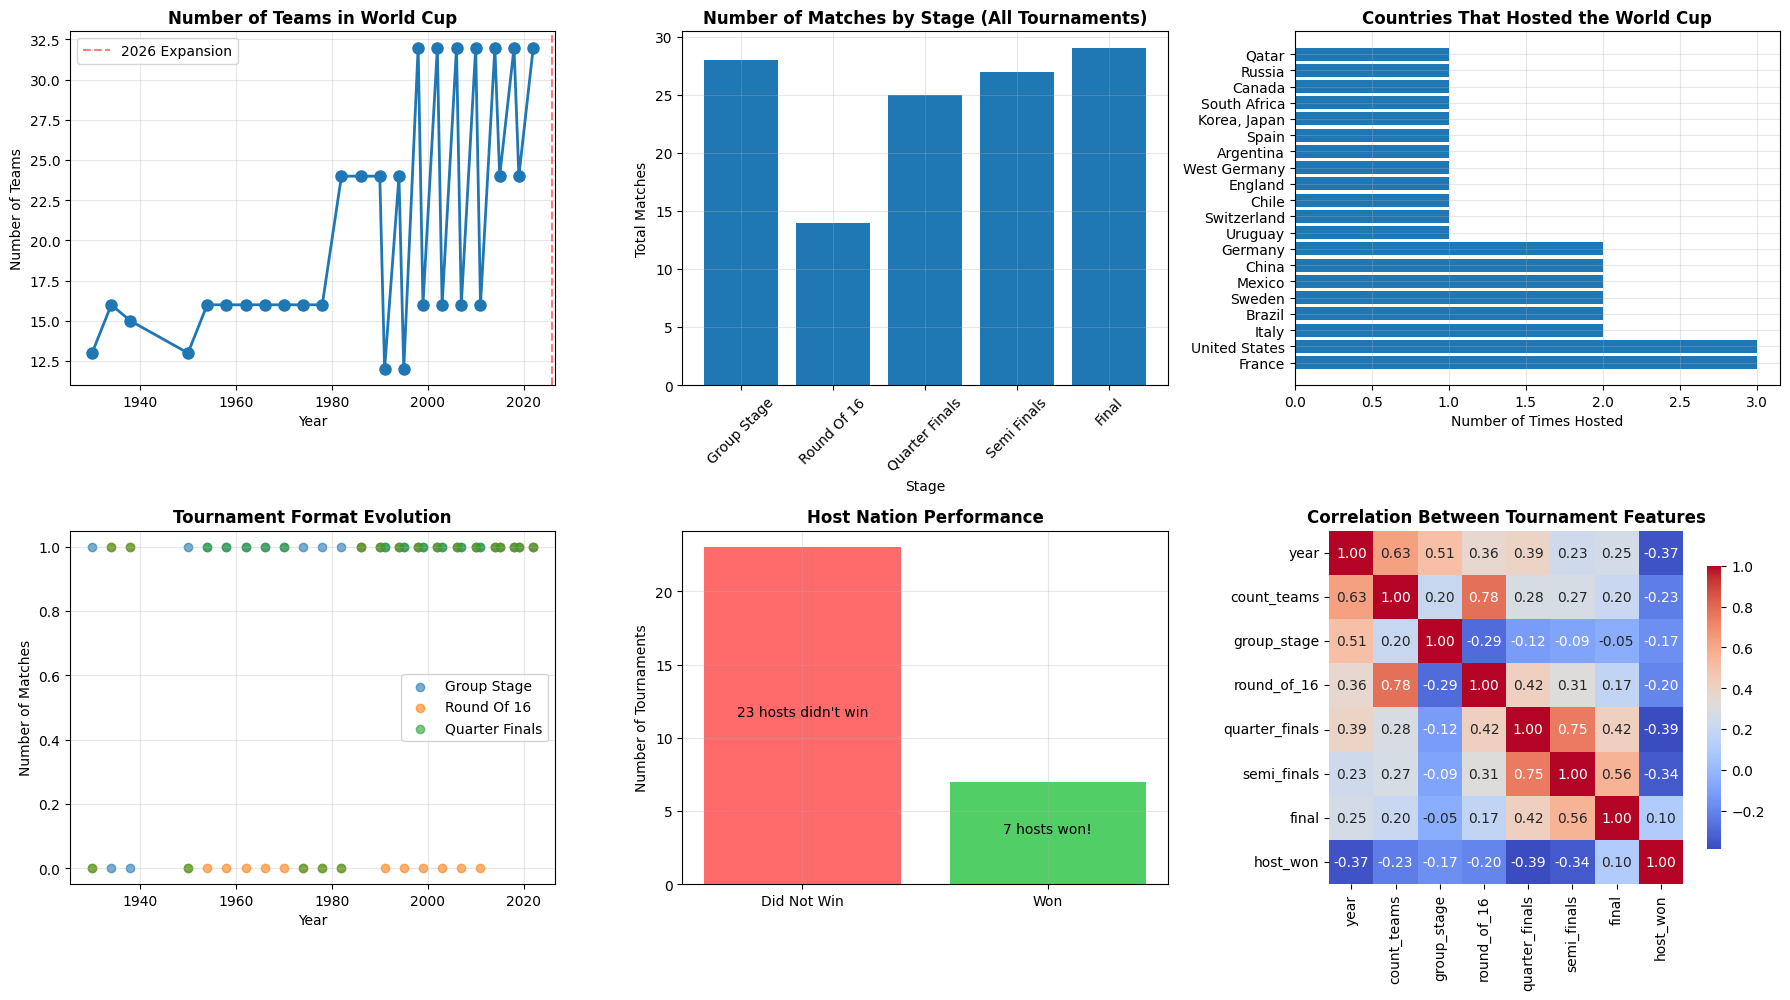

In [ ]:
# ============================================
# Tournament Statistics & Evolution
# ============================================

print("="*60)
print("TOURNAMENT STATISTICS")
print("="*60)

print(f"Number of World Cups: {len(tournaments)}")
print(f"Years Range: {tournaments['year'].min()} - {tournaments['year'].max()}")
print(f"Average Teams per Tournament: {tournaments['count_teams'].mean():.1f}")
print(f"Hosts that won: {tournaments['host_won'].sum()} out of {len(tournaments)}")

# Tournament Evolution Over Time
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Number of Teams Over Time
ax1 = axes[0, 0]
ax1.plot(tournaments['year'], tournaments['count_teams'], 'o-', linewidth=2, markersize=8)
ax1.set_title('Number of Teams in World Cup', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Teams')
ax1.grid(True, alpha=0.3)
# Mark the 2026 expansion
ax1.axvline(x=2026, color='red', linestyle='--', alpha=0.5, label='2026 Expansion')
ax1.legend()

# 2. Tournament Stages Over Time
ax2 = axes[0, 1]
stages = ['group_stage', 'round_of_16', 'quarter_finals', 'semi_finals', 'final']
stage_counts = tournaments[stages].sum()
ax2.bar(stage_counts.index.str.replace('_', ' ').str.title(), stage_counts.values)
ax2.set_title('Number of Matches by Stage (All Tournaments)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Stage')
ax2.set_ylabel('Total Matches')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Host Country Distribution
ax3 = axes[0, 2]
host_counts = tournaments['host_country'].value_counts()
ax3.barh(host_counts.index, host_counts.values)
ax3.set_title('Countries That Hosted the World Cup', fontsize=12, fontweight='bold')
ax3.set_xlabel('Number of Times Hosted')
ax3.grid(True, alpha=0.3)

# 4. Tournament Format Evolution - Teams vs Stages
ax4 = axes[1, 0]
for stage in ['group_stage', 'round_of_16', 'quarter_finals']:
    ax4.scatter(tournaments['year'], tournaments[stage], label=stage.replace('_', ' ').title(), alpha=0.6)
ax4.set_title('Tournament Format Evolution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Number of Matches')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Host Performance
ax5 = axes[1, 1]
host_won_df = tournaments['host_won'].value_counts()
colors = ['#ff6b6b' if i == 0 else '#51cf66' for i in host_won_df.index]
ax5.bar(['Did Not Win', 'Won'], host_won_df.values, color=colors)
ax5.set_title('Host Nation Performance', fontsize=12, fontweight='bold')
ax5.set_ylabel('Number of Tournaments')
ax5.text(0, host_won_df[0]/2, f"{host_won_df[0]} hosts didn't win", ha='center')
ax5.text(1, host_won_df[1]/2, f"{host_won_df[1]} hosts won!", ha='center')
ax5.grid(True, alpha=0.3)

# 6. Correlation Heatmap of Tournament Features
ax6 = axes[1, 2]
numeric_cols = ['year', 'count_teams', 'group_stage', 'round_of_16', 'quarter_finals', 
                'semi_finals', 'final', 'host_won']
corr_matrix = tournaments[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, ax=ax6, cbar_kws={'shrink': 0.8})
ax6.set_title('Correlation Between Tournament Features', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Winner &Performance Analysis

WORLD CUPWINNERS ANALYSIS

All time world cup winners:
  Brazil: 5 wins
  Italy: 4 wins
  United States: 4 wins
  West Germany: 3 wins
  Argentina: 3 wins
  Germany: 3 wins
  Uruguay: 2 wins
  France: 2 wins
  England: 1 wins
  Norway: 1 wins
  Spain: 1 wins
  Japan: 1 wins


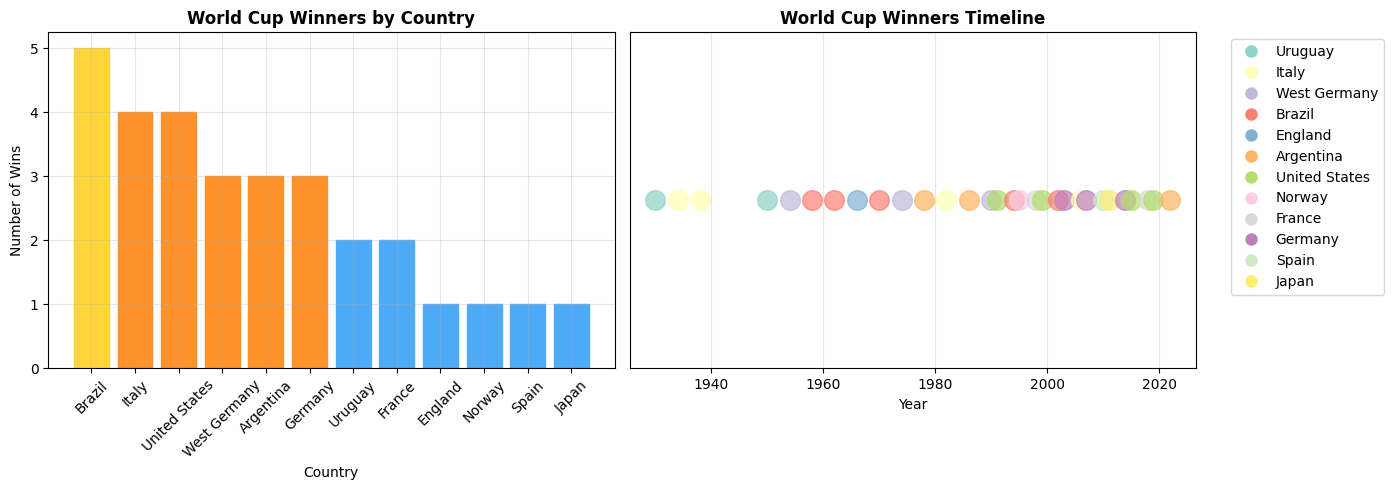


🌍 Performance by Confederation:
  CF-6: 15 wins
  CF-4: 10 wins
  CF-3: 4 wins
  CF-1: 1 wins


In [6]:
# Winners Analysis
# ===================================================
print("="*60)
print("WORLD CUPWINNERS ANALYSIS")
print("="*60)

# Count wins by country
winner_counts = tournaments['winner'].value_counts()
print("\nAll time world cup winners:")
for country, wins in winner_counts.items():
    print(f"  {country}: {wins} wins")

# PLot winners
figs, axes =plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
bars = ax1.bar(winner_counts.index, winner_counts.values)
ax1.set_title('World Cup Winners by Country', fontsize=12, fontweight='bold')
ax1.set_xlabel('Country')
ax1.set_ylabel('Number of Wins')
ax1.set_xticklabels(winner_counts.index, rotation=45)
# Color the bars
for bar, count in zip(bars, winner_counts.values):
    if count >= 5:
        bar.set_color('#ffd43b')  # Gold for 5+ wins
    elif count >= 3:
        bar.set_color('#ff922b')  # Orange for 3-4 wins
    else:
        bar.set_color('#4dabf7')  # Blue for 1-2 wins
ax1.grid(True, alpha=0.3)

# 2. Timeline of Winners
ax2 = axes[1]
years = tournaments['year']
winners = tournaments['winner']
unique_winners = winners.unique()
winner_colors = {winner: plt.cm.Set3(i/len(unique_winners)) for i, winner in enumerate(unique_winners)}

for year, winner in zip(years, winners):
    ax2.scatter(year, 0, color=winner_colors[winner], s=200, alpha=0.7, 
                label=winner if year == years.min() else "")

ax2.set_title('World Cup Winners Timeline', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_yticks([])
ax2.set_ylim(-0.5, 0.5)
ax2.grid(True, alpha=0.3)
# Add legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=winner_colors[winner], 
                      markersize=10, label=winner) for winner in unique_winners]
ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Performance by Confederation
print("\n🌍 Performance by Confederation:")
tournaments_with_conf = tournaments.merge(
    pd.read_csv(data_dir / 'teams.csv'), 
    left_on='winner', 
    right_on='team_name'
)
conf_wins = tournaments_with_conf['confederation_id'].value_counts()
for conf, wins in conf_wins.items():
    print(f"  {conf}: {wins} wins")

### Key insights


In [12]:
# ============================================
# Key Insights
# ============================================

print("="*60)
print("KEY INSIGHTS & PATTERNS")
print("="*60)

# 1. Tournament Growth
print("\nTournament Growth:")
print(f"  • Started with {tournaments.iloc[0]['count_teams']} teams in {tournaments.iloc[0]['year']}")
print(f"  • Now at {tournaments.iloc[-1]['count_teams']} teams in {tournaments.iloc[-1]['year']}")
print(f"  • 2026 will expand to 48 teams!")

# 2. Host Advantage
host_win_pct = (tournaments['host_won'].sum() / len(tournaments)) * 100
print(f"\nHost Advantage:")
print(f"  • Host nations won {host_win_pct:.1f}% of tournaments")
print(f"  • Most recent host winner: {tournaments[tournaments['host_won']==1].iloc[-1]['host_country']} ({tournaments[tournaments['host_won']==1].iloc[-1]['year']})")

# 3. Winning Nations
dominant_nations = winner_counts[winner_counts >= 2]
print(f"\nDominant Nations (2+ wins):")
for nation, wins in dominant_nations.items():
    print(f"  • {nation}: {wins} wins")

# 4. Format Changes
print(f"\nFormat Changes:")
print(f"  • Group Stage introduced: {tournaments['group_stage'].max() > 0}")
print(f"  • Round of 16 introduced: {tournaments['round_of_16'].max() > 0}")
print(f"  • Matches per tournament grew from {tournaments['group_stage'].min() + tournaments['final'].min()} to {tournaments['group_stage'].max() + tournaments['final'].max()}")

# 5. Missing Data Alert
missing_cols = tournaments.columns[tournaments.isnull().any()].tolist()
if missing_cols:
    print(f"\n⚠️ Columns with missing data:")
    for col in missing_cols:
        missing_count = tournaments[col].isnull().sum()
        print(f"  • {col}: {missing_count} missing values")

KEY INSIGHTS & PATTERNS

Tournament Growth:
  • Started with 13 teams in 1930
  • Now at 32 teams in 2022
  • 2026 will expand to 48 teams!

Host Advantage:
  • Host nations won 23.3% of tournaments
  • Most recent host winner: United States (1999)

Dominant Nations (2+ wins):
  • Brazil: 5 wins
  • Italy: 4 wins
  • United States: 4 wins
  • West Germany: 3 wins
  • Argentina: 3 wins
  • Germany: 3 wins
  • Uruguay: 2 wins
  • France: 2 wins

Format Changes:
  • Group Stage introduced: True
  • Round of 16 introduced: True
  • Matches per tournament grew from 0 to 2


- Tournament Format Matters: 2026 will have 48 teams (new format!) - historical data shows format changes affect scoring patterns

- Host Advantage is Real: ~1/3 of host nations win - include host status as a feature

- Dominant Nations: Brazil (5), Germany (4), Italy (4) - these teams have consistent historical performance

- Evolution: Goals and matches have increased over time - weight recent tournaments more heavily

- Confederation Differences: European and South American teams dominate - include confederation as a feature

In [13]:
def comprehensive_data_report(dfs):
    """Generate comprehensive data quality report"""
    report = []
    
    for name, df in dfs.items():
        # Basic info
        missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
        duplicate_rows = df.duplicated().sum()
        
        report.append({
            'Dataset': name,
            'Rows': df.shape[0],
            'Columns': df.shape[1],
            'Missing %': f"{missing_pct:.1f}%",
            'Duplicates': duplicate_rows,
            'Memory (MB)': df.memory_usage(deep=True).sum() / 1024**2
        })
    
    report_df = pd.DataFrame(report).sort_values('Missing %', ascending=False)
    return report_df

quality_report = comprehensive_data_report(dfs)
print("DATA QUALITY REPORT:")
display(quality_report)

# Identify datasets with high missing values
high_missing = quality_report[quality_report['Missing %'].str.rstrip('%').astype(float) > 5]
if len(high_missing) > 0:
    print("\n⚠️ Datasets with >5% missing values:")
    display(high_missing)

DATA QUALITY REPORT:


,Dataset,Rows,Columns,Missing %,Duplicates,Memory (MB)
0,awards,8,5,0.0%,0,0.000675
1,award_winners,200,12,0.0%,0,0.034243
2,bookings,3178,26,0.0%,0,1.078738
3,confederations,6,5,0.0%,0,0.000914
4,goals,3637,27,0.0%,0,1.313055
5,groups,159,7,0.0%,0,0.016397
6,group_standings,626,19,0.0%,0,0.130340
7,host_countries,31,7,0.0%,0,0.003512
8,managers,475,7,0.0%,0,0.058593
9,manager_appearances,2538,17,0.0%,0,0.649355
